# Sort-Order Drift: `ORDER BY name` is a collation, not an order

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/sort-order-drift/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/sort-order-drift/demo.ipynb)

**Day 150 of the FDE portfolio.** A text column, ten collations, and the
question nobody asks of `ORDER BY`: is the answer *determined*?

A collation is three decisions the SQL never states:

1. **which sequence the characters are in** - locale tailoring,
2. **how many levels of difference count as a difference** - strength,
3. **whether two strings that compare equal are the same value** for `=`,
   `DISTINCT`, `GROUP BY` and `UNIQUE` - determinism.

Decision 1 makes two servers return the same rows in different orders.
Decision 2 creates **ties**, and the order inside a tie is whatever the plan
produced - so paginating it drops rows with no error. Decision 3 changes how
many rows a report returns.

What this notebook builds, in order:

1. the column - 28 ordinary names, two of which are the same string
2. a sort key, three levels deep, tailored per locale
3. ten orders, and how many of the 45 collation pairs agree
4. the ties, and the two very different things a tie can cost
5. what OFFSET and keyset pagination do to a tied sort
6. a range predicate that returns a different number of rows per collation
7. the one-clause fix, verified


## 1. The column

Nothing here is exotic. Nordic and German surnames, a Turkish name, a Czech
name, a company with a fullwidth `A`, three inventory codes with digit runs,
and one name written twice - once as NFC (`é` is one code point) and once as
NFD (`e` + U+0301). Those two rows are **the same string** by Unicode's own
definition of equivalence.


In [1]:
from __future__ import annotations

import unicodedata
from dataclasses import dataclass
from typing import Dict, Tuple


@dataclass(frozen=True)
class Row:
    id: int
    name: str
    note: str

    @property
    def display(self) -> str:
        """The name with invisible structure made visible."""
        out = []
        for ch in self.name:
            if unicodedata.combining(ch):
                out.append(f"<U+{ord(ch):04X}>")
            else:
                out.append(ch)
        return "".join(out)


CORPUS: Tuple[Row, ...] = (
    Row(1, "Aaberg", "plain ASCII, sorts first almost everywhere"),
    Row(2, "Åberg", "A-ring: with A in en/de, a letter after Z in sv"),
    Row(3, "aaberg", "same letters as row 1, different case"),
    Row(4, "Ahtari", "unaccented twin of row 5"),
    Row(5, "Ähtäri", "A-diaeresis: with A in de, after Z in sv"),
    Row(6, "Muench", "sits between Mueller and Muller under the phonebook rule"),
    Row(7, "Mueller", "the ae-spelling"),
    Row(8, "Müller", "u-diaeresis: = Muller in DIN 5007-1, = Mueller in the phonebook order"),
    Row(9, "Muller", "the unaccented spelling"),
    Row(10, "Straße", "sharp s: expands to ss in the phonebook order"),
    Row(11, "Strasse", "the ss-spelling of row 10"),
    Row(12, "José", "NFC: e-acute is one code point (U+00E9)"),
    Row(13, "José", "NFD: the same string as row 12, as e + U+0301"),
    Row(14, "Jose", "no accent at all"),
    Row(15, "Istanbul", "capital I - lowercases to i everywhere but Turkish"),
    Row(16, "Işık", "dotless i and s-cedilla: separate letters in Turkish"),
    Row(17, "Isik", "the ASCII spelling of row 16"),
    Row(18, "van der Berg", "spaces: variable-weighted in ICU, ignored by glibc"),
    Row(19, "vanderBerg", "the same letters as row 18 with the spaces removed"),
    Row(20, "Van Der Berg", "the same letters again, different case"),
    Row(21, "Item 9", "digit run: after Item 10 lexicographically, before it numerically"),
    Row(22, "Item 10", "two digits"),
    Row(23, "Item 100", "three digits"),
    Row(24, "Čapek", "C-caron: with C in en, its own letter in cs"),
    Row(25, "Capek", "the unaccented twin of row 24"),
    Row(26, "Ａ Corp", "fullwidth A (U+FF21) - inside the BMP"),
    Row(27, "\U0001f40d Python Co", "U+1F40D - above the BMP, so a surrogate pair in UTF-16"),
    Row(28, "Zoe", "last under most tailorings, not under all"),
)


print(f"{len(CORPUS)} rows\n")
for r in CORPUS:
    cps = " ".join(f"U+{ord(c):04X}" for c in r.name)
    flag = "  <-- non-ASCII" if any(ord(c) > 0x7F for c in r.name) else ""
    print(f"{r.id:2d}  {r.display:<16s}{flag}")
    if flag:
        print(f"    {cps}")

28 rows

 1  Aaberg          
 2  Åberg             <-- non-ASCII
    U+00C5 U+0062 U+0065 U+0072 U+0067
 3  aaberg          
 4  Ahtari          
 5  Ähtäri            <-- non-ASCII
    U+00C4 U+0068 U+0074 U+00E4 U+0072 U+0069
 6  Muench          
 7  Mueller         
 8  Müller            <-- non-ASCII
    U+004D U+00FC U+006C U+006C U+0065 U+0072
 9  Muller          
10  Straße            <-- non-ASCII
    U+0053 U+0074 U+0072 U+0061 U+00DF U+0065
11  Strasse         
12  José              <-- non-ASCII
    U+004A U+006F U+0073 U+00E9
13  Jose<U+0301>      <-- non-ASCII
    U+004A U+006F U+0073 U+0065 U+0301
14  Jose            
15  Istanbul        
16  Işık              <-- non-ASCII
    U+0049 U+015F U+0131 U+006B
17  Isik            
18  van der Berg    
19  vanderBerg      
20  Van Der Berg    
21  Item 9          
22  Item 10         
23  Item 100        
24  Čapek             <-- non-ASCII
    U+010C U+0061 U+0070 U+0065 U+006B
25  Capek           
26  Ａ Corp            <-- n

## 2. The sort key

A collation compares *weights*, not characters, and it compares them in
levels: base letter first, then accents, then case. Punctuation is
"variable" - ICU shifts it to a fourth level, glibc drops it outright.

The cell below is lifted verbatim from `collate.py` so the notebook cannot
drift from the engine. Ten collations are defined:

| key | models |
|---|---|
| `C` | PostgreSQL `COLLATE "C"`, SQLite `BINARY`, `LC_ALL=C sort` |
| `UTF16_BIN` | Java `String.compareTo`, JS `Array#sort`, SQL Server `*_BIN2` |
| `en_US_icu` | ICU root/en, PostgreSQL `en-US-x-icu` |
| `de_DIN` | DIN 5007-1 |
| `de_phonebook` | DIN 5007-2, ICU `de-u-co-phonebk` - same language, different answer |
| `sv_SE` | ICU `sv` - å, ä, ö are three letters after Z |
| `tr_TR` | ICU `tr` - dotless ı is a letter before i |
| `ai_ci` | MySQL 8's **default** `utf8mb4_0900_ai_ci` - and nondeterministic |
| `glibc_en_US` | glibc `en_US.UTF-8`, the PostgreSQL default on most Linux hosts |
| `icu_numeric` | ICU `kn-true` - a digit run is a number |


In [2]:
from __future__ import annotations

import unicodedata
from dataclasses import dataclass, field
from enum import Enum
from itertools import combinations
from typing import Dict, List, Optional, Sequence, Tuple

BASE_ALPHABET = "abcdefghijklmnopqrstuvwxyz"


ACCENT: Dict[str, int] = {
    "\u0301": 2,  # acute
    "\u0300": 3,  # grave
    "\u0302": 4,  # circumflex
    "\u0303": 5,  # tilde
    "\u0308": 6,  # diaeresis
    "\u030a": 7,  # ring above
    "\u0327": 8,  # cedilla
    "\u030c": 9,  # caron
    "\u0306": 10,  # breve
    "\u0307": 11,  # dot above
}

# Primary weight classes, so every weight is a comparable (class, value) pair.
# The order of the classes is DUCET's: punctuation, then symbols, then digits,
# then the tailored Latin alphabet, then every other script by code point.


CLS_VARIABLE = 0  # space and punctuation, when not ignored


CLS_SYMBOL = 1


CLS_DIGIT = 2


CLS_LETTER = 3


CLS_OTHER = 4  # other scripts and anything with no fold

# Letters with no canonical decomposition, folded to a base plus a secondary
# difference - which is what ICU's root collation does with them.


FOLD_SECONDARY = 12


BASE_FOLD = {
    "\u0131": "i",   # dotless i
    "\u00f8": "o",   # o with stroke
    "\u00e6": "ae",
    "\u0153": "oe",
    "\u00df": "ss",  # sharp s
    "\u0111": "d",
    "\u0142": "l",
    "\u00f0": "d",
    "\u00fe": "th",
}

# Sentinel code points used to lift a tailored letter out of its base letter.


SENT = {
    "aring": "\ue001",
    "adia": "\ue002",
    "odia": "\ue003",
    "udia": "\ue004",
    "ccedil": "\ue005",
    "gbreve": "\ue006",
    "dotless": "\ue007",
    "scedil": "\ue008",
    "ccaron": "\ue009",
}


@dataclass(frozen=True)
class Collation:
    key_name: str
    models: str
    kind: str = "uca"  # "bytes" | "utf16" | "uca"
    alphabet: str = BASE_ALPHABET
    pre_map: Tuple[Tuple[str, str], ...] = ()
    variable: str = "shifted"  # "shifted" | "non-ignorable" | "ignored"
    numeric: bool = False
    strength: int = 3  # 1 primary, 2 +accents, 3 +case
    deterministic: bool = True
    lower: str = "root"  # "root" | "tr"
    libc: Optional[str] = None
    note: str = ""
    _pre: Dict[str, str] = field(default_factory=dict, compare=False, repr=False)

    def __post_init__(self) -> None:
        object.__setattr__(self, "_pre", dict(self.pre_map))


DE_PHONEBOOK = (
    ("ä", "ae"),
    ("ö", "oe"),
    ("ü", "ue"),
    ("ß", "ss"),
)


SV_TAILOR = (
    ("å", SENT["aring"]),
    ("ä", SENT["adia"]),
    ("ö", SENT["odia"]),
)


TR_TAILOR = (
    ("ç", SENT["ccedil"]),
    ("ğ", SENT["gbreve"]),
    ("ı", SENT["dotless"]),
    ("ö", SENT["odia"]),
    ("ş", SENT["scedil"]),
    ("ü", SENT["udia"]),
)


COLLATIONS: Tuple[Collation, ...] = (
    Collation(
        key_name="C",
        models='PostgreSQL COLLATE "C", SQLite BINARY, LC_ALL=C sort',
        kind="bytes",
        note="UTF-8 byte order. All uppercase before all lowercase; no locale, "
        "no version, no ties.",
    ),
    Collation(
        key_name="UTF16_BIN",
        models="Java String.compareTo, JS Array#sort, SQL Server *_BIN2 on nvarchar",
        kind="utf16",
        note="UTF-16 code-unit order. Agrees with C on the BMP and disagrees "
        "above it, because a surrogate pair starts at U+D800.",
    ),
    Collation(
        key_name="en_US_icu",
        models="ICU root/en collation, PostgreSQL ICU en-US-x-icu, MySQL utf8mb4_0900_as_cs",
        libc="en_US.UTF-8",
        note="Three levels: base letter, then accent, then case.",
    ),
    Collation(
        key_name="de_DIN",
        models="DIN 5007-1, ICU de",
        libc="de_DE.UTF-8",
        note="Umlauts are the base vowel with a secondary difference.",
    ),
    Collation(
        key_name="de_phonebook",
        models="DIN 5007-2, ICU de-u-co-phonebk",
        pre_map=DE_PHONEBOOK,
        note="Umlauts expand: ae, oe, ue, ss. Same language as de_DIN, "
        "different answer.",
    ),
    Collation(
        key_name="sv_SE",
        models="ICU sv, PostgreSQL sv-SE-x-icu",
        alphabet=BASE_ALPHABET + SENT["aring"] + SENT["adia"] + SENT["odia"],
        pre_map=SV_TAILOR,
        libc="sv_SE.UTF-8",
        note="Three letters after Z, not three accented vowels.",
    ),
    Collation(
        key_name="tr_TR",
        models="ICU tr, PostgreSQL tr-TR-x-icu",
        alphabet="abc"
        + SENT["ccedil"]
        + "defg"
        + SENT["gbreve"]
        + "h"
        + SENT["dotless"]
        + "ijklmno"
        + SENT["odia"]
        + "pqrs"
        + SENT["scedil"]
        + "tu"
        + SENT["udia"]
        + "vwxyz",
        pre_map=TR_TAILOR,
        lower="tr",
        libc="tr_TR.UTF-8",
        note="Dotless i is a letter before i, and I lowercases to it.",
    ),
    Collation(
        key_name="ai_ci",
        models="MySQL 8 default utf8mb4_0900_ai_ci, PostgreSQL nondeterministic ICU colStrength=primary",
        strength=1,
        deterministic=False,
        note="Primary level only. Accent- and case-insensitive, and equality "
        "follows the collation, so DISTINCT and UNIQUE change meaning.",
    ),
    Collation(
        key_name="glibc_en_US",
        models="glibc en_US.UTF-8 (PostgreSQL default on most Linux hosts)",
        variable="ignored",
        note="Punctuation and space are dropped before comparing, so two "
        "different strings can be exactly equal at every level.",
    ),
    Collation(
        key_name="icu_numeric",
        models="ICU kn-true (en-u-kn-true), natural sort",
        numeric=True,
        note="A digit run is one number, not a sequence of characters.",
    ),
)


def locale_lower(ch: str, mode: str) -> str:
    """Lowercase one character the way `mode` does it."""
    if mode == "tr":
        if ch == "I":
            return "ı"
        if ch == "İ":  # I with dot above
            return "i"
    return ch.lower()


def _is_variable(ch: str) -> bool:
    cat = unicodedata.category(ch)
    return cat.startswith("Z") or cat.startswith("P")


def sort_key(s: str, coll: Collation) -> Tuple:
    """The comparison key `ORDER BY s COLLATE coll` actually compares."""
    if coll.kind == "bytes":
        return tuple(s.encode("utf-8"))
    if coll.kind == "utf16":
        raw = s.encode("utf-16-be")
        return tuple((raw[i] << 8) | raw[i + 1] for i in range(0, len(raw), 2))

    text = unicodedata.normalize("NFC", s)
    # Tailoring runs on the composed form, before decomposition, or the
    # decomposition would destroy the very letter being tailored.
    buf: List[Tuple[str, int]] = []  # (char, case weight)
    for ch in text:
        low = locale_lower(ch, coll.lower)
        case_w = 1 if low == ch else 2
        mapped = coll._pre.get(low, low)
        for m in mapped:
            buf.append((m, case_w))

    primary: List[Tuple[int, int]] = []
    secondary: List[int] = []
    tertiary: List[int] = []
    quaternary: List[int] = []

    i = 0
    while i < len(buf):
        ch, case_w = buf[i]
        # A combining mark attaches to the base letter that came before it.
        if unicodedata.combining(ch):
            if secondary:
                secondary[-1] = ACCENT.get(ch, 12)
            else:  # a mark with no base: treat as its own element
                primary.append((CLS_OTHER, ord(ch)))
                secondary.append(1)
                tertiary.append(1)
            i += 1
            continue

        decomposed = unicodedata.normalize("NFD", ch)
        base = decomposed[0]
        marks = [m for m in decomposed[1:] if unicodedata.combining(m)]

        if _is_variable(base):
            if coll.variable == "ignored":
                pass  # never compared at any level
            elif coll.variable == "shifted":
                quaternary.append(ord(base))
            else:  # non-ignorable: punctuation sorts before every letter
                primary.append((CLS_VARIABLE, ord(base)))
                secondary.append(1)
                tertiary.append(1)
            i += 1
            continue

        if base.isdigit():
            if coll.numeric:
                run = ""
                while i < len(buf) and buf[i][0].isdigit():
                    run += buf[i][0]
                    i += 1
                primary.append((CLS_DIGIT, int(run)))
                secondary.append(1)
                tertiary.append(1)
                continue
            primary.append((CLS_DIGIT, ord(base)))
            secondary.append(1)
            tertiary.append(1)
            i += 1
            continue

        acc = max([ACCENT.get(m, 12) for m in marks], default=1)
        idx = coll.alphabet.find(base)
        if idx >= 0:
            primary.append((CLS_LETTER, idx))
            secondary.append(acc)
            tertiary.append(case_w)
            i += 1
            continue

        # No tailoring for this character. Two fallbacks, in ICU's spirit:
        # a compatibility decomposition (fullwidth A is an A), then an
        # explicit fold for the letters Unicode never decomposes (dotless i
        # is an i, sharp s is ss) - each with a secondary difference so the
        # fold is not silent.
        fold = BASE_FOLD.get(base)
        if fold is None:
            kd = "".join(
                c for c in unicodedata.normalize("NFKD", base) if not unicodedata.combining(c)
            )
            if kd != base and all(c.lower() in coll.alphabet for c in kd if c.isalpha()):
                fold = "".join(c.lower() for c in kd)
        if fold is not None:
            for j, fch in enumerate(fold):
                primary.append((CLS_LETTER, coll.alphabet.find(fch)))
                secondary.append(FOLD_SECONDARY if j == 0 else 1)
                tertiary.append(case_w)
            i += 1
            continue

        cat = unicodedata.category(base)
        cls = CLS_SYMBOL if cat.startswith("S") else CLS_OTHER
        primary.append((cls, ord(base)))
        secondary.append(acc)
        tertiary.append(case_w)
        i += 1

    levels: List[Tuple] = [tuple(primary)]
    if coll.strength >= 2:
        levels.append(tuple(secondary))
    if coll.strength >= 3:
        levels.append(tuple(tertiary))
    if coll.variable == "shifted":
        levels.append(tuple(quaternary))
    return tuple(levels)


COLLATION_BY_NAME = {c.key_name: c for c in COLLATIONS}
print(f"{len(COLLATIONS)} collations\n")
for c in COLLATIONS:
    print(f"  {c.key_name:13s} strength {c.strength}  "
          f"{'nondeterministic' if not c.deterministic else 'deterministic  '}  "
          f"variable={c.variable}")

10 collations

  C             strength 3  deterministic    variable=shifted
  UTF16_BIN     strength 3  deterministic    variable=shifted
  en_US_icu     strength 3  deterministic    variable=shifted
  de_DIN        strength 3  deterministic    variable=shifted
  de_phonebook  strength 3  deterministic    variable=shifted
  sv_SE         strength 3  deterministic    variable=shifted
  tr_TR         strength 3  deterministic    variable=shifted
  ai_ci         strength 1  nondeterministic  variable=shifted
  glibc_en_US   strength 3  deterministic    variable=ignored
  icu_numeric   strength 3  deterministic    variable=shifted


### What a key looks like

Three levels for `Müller`, and the same three for `Mueller`, under two German
standards. Under the phonebook rule the two keys are **identical**.


In [3]:
for name in ("Müller", "Mueller", "Muller"):
    for key_name in ("de_DIN", "de_phonebook"):
        k = sort_key(name, COLLATION_BY_NAME[key_name])
        print(f"{name:<9s} {key_name:<13s} primary={k[0]}\n{'':24s}secondary={k[1]} tertiary={k[2]}")
    print()

pb = COLLATION_BY_NAME["de_phonebook"]
print("phonebook: Müller == Mueller ?", sort_key("Müller", pb) == sort_key("Mueller", pb))
din = COLLATION_BY_NAME["de_DIN"]
print("DIN 5007-1: Müller == Mueller ?", sort_key("Müller", din) == sort_key("Mueller", din))

Müller    de_DIN        primary=((3, 12), (3, 20), (3, 11), (3, 11), (3, 4), (3, 17))
                        secondary=(1, 6, 1, 1, 1, 1) tertiary=(2, 1, 1, 1, 1, 1)
Müller    de_phonebook  primary=((3, 12), (3, 20), (3, 4), (3, 11), (3, 11), (3, 4), (3, 17))
                        secondary=(1, 1, 1, 1, 1, 1, 1) tertiary=(2, 1, 1, 1, 1, 1, 1)

Mueller   de_DIN        primary=((3, 12), (3, 20), (3, 4), (3, 11), (3, 11), (3, 4), (3, 17))
                        secondary=(1, 1, 1, 1, 1, 1, 1) tertiary=(2, 1, 1, 1, 1, 1, 1)
Mueller   de_phonebook  primary=((3, 12), (3, 20), (3, 4), (3, 11), (3, 11), (3, 4), (3, 17))
                        secondary=(1, 1, 1, 1, 1, 1, 1) tertiary=(2, 1, 1, 1, 1, 1, 1)

Muller    de_DIN        primary=((3, 12), (3, 20), (3, 11), (3, 11), (3, 4), (3, 17))
                        secondary=(1, 1, 1, 1, 1, 1) tertiary=(2, 1, 1, 1, 1, 1)
Muller    de_phonebook  primary=((3, 12), (3, 20), (3, 11), (3, 11), (3, 4), (3, 17))
                        secondary=(

## 3. Ten orders, and how many agree

`order()` is a plain stable sort on the key - which is what every engine does
once it has committed to a plan.


In [4]:
import pandas as pd


def order(rows, coll):
    return sorted(rows, key=lambda r: sort_key(r.name, coll))


def positions(coll, rows=CORPUS):
    return {r.id: i for i, r in enumerate(order(rows, coll))}


table = pd.DataFrame({c.key_name: [r.display for r in order(CORPUS, c)] for c in COLLATIONS})
table.index = [f"#{i}" for i in range(len(CORPUS))]
identical = [
    (a.key_name, b.key_name)
    for a, b in combinations(COLLATIONS, 2)
    if [r.id for r in order(CORPUS, a)] == [r.id for r in order(CORPUS, b)]
]
print(f"collation pairs returning the identical sequence: {len(identical)} of "
      f"{len(list(combinations(COLLATIONS, 2)))} -> {identical}\n")
print("ORDER BY name LIMIT 1, which is also MIN(name):")
for c in COLLATIONS:
    print(f"  {c.key_name:13s} {order(CORPUS, c)[0].display!r}")
table.head(12)

collation pairs returning the identical sequence: 1 of 45 -> [('en_US_icu', 'de_DIN')]

ORDER BY name LIMIT 1, which is also MIN(name):
  C             'Aaberg'
  UTF16_BIN     'Aaberg'
  en_US_icu     '🐍 Python Co'
  de_DIN        '🐍 Python Co'
  de_phonebook  '🐍 Python Co'
  sv_SE         '🐍 Python Co'
  tr_TR         '🐍 Python Co'
  ai_ci         '🐍 Python Co'
  glibc_en_US   '🐍 Python Co'
  icu_numeric   '🐍 Python Co'


,C,UTF16_BIN,en_US_icu,de_DIN,de_phonebook,sv_SE,tr_TR,ai_ci,glibc_en_US,icu_numeric
#0,Aaberg,Aaberg,🐍 Python Co,🐍 Python Co,🐍 Python Co,🐍 Python Co,🐍 Python Co,🐍 Python Co,🐍 Python Co,🐍 Python Co
#1,Ahtari,Ahtari,aaberg,aaberg,aaberg,aaberg,aaberg,Aaberg,aaberg,aaberg
#2,Capek,Capek,Aaberg,Aaberg,Aaberg,Aaberg,Aaberg,aaberg,Aaberg,Aaberg
#3,Isik,Isik,Åberg,Åberg,Åberg,Ａ Corp,Åberg,Åberg,Åberg,Åberg
#4,Istanbul,Istanbul,Ａ Corp,Ａ Corp,Ａ Corp,Ahtari,Ａ Corp,Ａ Corp,Ａ Corp,Ａ Corp
#5,Item 10,Item 10,Ahtari,Ahtari,Ähtäri,Capek,Ahtari,Ahtari,Ahtari,Ahtari
#6,Item 100,Item 100,Ähtäri,Ähtäri,Ahtari,Čapek,Ähtäri,Ähtäri,Ähtäri,Ähtäri
#7,Item 9,Item 9,Capek,Capek,Capek,Isik,Capek,Čapek,Capek,Capek
#8,Işık,Işık,Čapek,Čapek,Čapek,Işık,Čapek,Capek,Čapek,Čapek
#9,Jose,Jose,Isik,Isik,Isik,Istanbul,Isik,Işık,Isik,Isik


### How far one row moves

`Åberg` is a vowel with a ring in English and German, and a **letter after Z**
in Swedish. `Item 9` is after `Item 10` unless the collation reads digit runs
as numbers.


In [5]:
pos = {c.key_name: positions(c) for c in COLLATIONS}
spread = []
for r in CORPUS:
    ps = [pos[c.key_name][r.id] for c in COLLATIONS]
    spread.append({"name": r.display, "first": min(ps), "last": max(ps), "spread": max(ps) - min(ps)})
pd.DataFrame(sorted(spread, key=lambda d: -d["spread"])[:8])

,name,first,last,spread
0,🐍 Python Co,0,27,27
1,Ａ Corp,3,27,24
2,Åberg,3,26,23
3,Ähtäri,5,27,22
4,aaberg,1,20,19
5,Čapek,6,25,19
6,Jose,9,17,8
7,Van Der Berg,18,26,8


## 4. The ties

Two rows are tied when their keys are **equal**. A stable sort then preserves
whatever physical order it was handed, so the result order inside a tie group
is a property of the plan, not of the query.

Two very different costs live here:

- a **deterministic** collation's ties are ordering only. PostgreSQL still
  compares bytes for `=`, so the rows stay distinct and only the order is
  undefined. This is the one that shows up as *a report whose rows moved*.
- a **nondeterministic** collation makes the tie into equality, so
  `DISTINCT`, `GROUP BY` and `UNIQUE` change meaning, and the row *count* moves.


In [6]:
class Verdict(str, Enum):
    STABLE_TOTAL = "stable-total"
    TOTAL = "total"
    TIED = "tied"
    MERGING = "merging"


def tie_groups(coll, rows=CORPUS):
    groups = {}
    for r in rows:
        groups.setdefault(sort_key(r.name, coll), []).append(r)
    return [g for g in groups.values() if len(g) > 1]


def verdict(coll, rows=CORPUS):
    if not tie_groups(coll, rows):
        return Verdict.STABLE_TOTAL if coll.kind in ("bytes", "utf16") else Verdict.TOTAL
    return Verdict.TIED if coll.deterministic else Verdict.MERGING


def distinct_count(coll, rows=CORPUS):
    if coll.deterministic:
        return len({r.name for r in rows})
    return len({sort_key(r.name, coll) for r in rows})


for c in COLLATIONS:
    groups = tie_groups(c)
    print(f"{c.key_name:13s} {verdict(c).value:13s} "
          f"{len(groups):2d} tie groups  DISTINCT(name)={distinct_count(c):2d}")
    for g in groups:
        print(f"{'':15s}{' = '.join(r.display for r in g)}")

C             stable-total   0 tie groups  DISTINCT(name)=28
UTF16_BIN     stable-total   0 tie groups  DISTINCT(name)=28
en_US_icu     tied           1 tie groups  DISTINCT(name)=28
               José = Jose<U+0301>
de_DIN        tied           1 tie groups  DISTINCT(name)=28
               José = Jose<U+0301>
de_phonebook  tied           3 tie groups  DISTINCT(name)=28
               Mueller = Müller
               Straße = Strasse
               José = Jose<U+0301>
sv_SE         tied           1 tie groups  DISTINCT(name)=28
               José = Jose<U+0301>
tr_TR         tied           1 tie groups  DISTINCT(name)=28
               José = Jose<U+0301>
ai_ci         merging        8 tie groups  DISTINCT(name)=19
               Aaberg = aaberg
               Ahtari = Ähtäri
               Müller = Muller
               Straße = Strasse
               José = Jose<U+0301> = Jose
               Işık = Isik
               van der Berg = Van Der Berg
               Čapek = Capek
glibc_e

Note the line that has nothing to do with any locale: **every**
Unicode-aware collation ties `José` with `José`, because they are the same
string. Only the byte orders escape it, by not knowing what a string is.
That is also why no collation here earns the `total` verdict.

And note what `ai_ci` - MySQL 8's *default* - does to a uniqueness constraint.


In [7]:
ai = COLLATION_BY_NAME["ai_ci"]
violations = [
    (a, b)
    for a, b in combinations(CORPUS, 2)
    if a.name != b.name and sort_key(a.name, ai) == sort_key(b.name, ai)
]
print(f"UNIQUE(name) under {ai.key_name} rejects {len(violations)} pairs of different strings:")
for a, b in violations:
    print(f"  {a.display!r:<16s} = {b.display!r}")
print(f"\nCOUNT(DISTINCT name): {distinct_count(ai)} under ai_ci, "
      f"{len({r.name for r in CORPUS})} under every deterministic collation")

UNIQUE(name) under ai_ci rejects 10 pairs of different strings:
  'Aaberg'         = 'aaberg'
  'Ahtari'         = 'Ähtäri'
  'Müller'         = 'Muller'
  'Straße'         = 'Strasse'
  'José'           = 'Jose<U+0301>'
  'José'           = 'Jose'
  'Jose<U+0301>'   = 'Jose'
  'Işık'           = 'Isik'
  'van der Berg'   = 'Van Der Berg'
  'Čapek'          = 'Capek'

COUNT(DISTINCT name): 19 under ai_ci, 28 under every deterministic collation


## 5. Pagination

Each page is a separate execution, so each may be handed a different physical
row order: insertion order, a backward index scan, a table rewritten by
`VACUUM FULL`. Three plans below, and four pagination schemes:

- `OFFSET` - `ORDER BY name LIMIT n OFFSET k`
- `OFFSET` + a unique tiebreak - `ORDER BY name, id`
- keyset with `>` - `WHERE name > $last`
- keyset with `>=` - `WHERE name >= $last`


In [8]:
def plan_orders(rows=CORPUS):
    base = list(rows)
    return [base, list(reversed(base)), sorted(base, key=lambda r: (len(r.name), r.id))]


def offset_pagination(coll, page_size, rows=CORPUS, tiebreak=False):
    plans = plan_orders(rows)
    seen = []
    for page_no in range((len(rows) + page_size - 1) // page_size):
        physical = plans[page_no % len(plans)]
        key = (lambda r: (sort_key(r.name, coll), r.id)) if tiebreak else (lambda r: sort_key(r.name, coll))
        ordered = sorted(physical, key=key)
        seen.extend(r.id for r in ordered[page_no * page_size:(page_no + 1) * page_size])
    lost = sorted({r.id for r in rows} - set(seen))
    dup = sorted(i for i in set(seen) if seen.count(i) > 1)
    return lost, dup


def keyset_pagination(coll, page_size, rows=CORPUS, strict=True):
    plans = plan_orders(rows)
    seen, last_key, prev, stalled = [], None, None, False
    for page_no in range(len(rows) + 1):
        ordered = sorted(plans[page_no % len(plans)], key=lambda r: sort_key(r.name, coll))
        if last_key is not None:
            ordered = [r for r in ordered
                       if (sort_key(r.name, coll) > last_key if strict
                           else sort_key(r.name, coll) >= last_key)]
        page = ordered[:page_size]
        if not page:
            break
        ids = tuple(r.id for r in page)
        if prev is not None and set(ids) == set(prev):
            stalled = True
            break
        seen.extend(ids)
        prev = ids
        last_key = sort_key(page[-1].name, coll)
    lost = sorted({r.id for r in rows} - set(seen))
    dup = sorted(i for i in set(seen) if seen.count(i) > 1)
    return lost, dup, stalled


PAGE_SIZES = (2, 3, 4, 5, 6, 7, 8, 10)
rows_out = []
for c in COLLATIONS:
    for n in PAGE_SIZES:
        lost, dup = offset_pagination(c, n)
        tlost, tdup = offset_pagination(c, n, tiebreak=True)
        klost, _, _ = keyset_pagination(c, n, strict=True)
        _, kdup, stall = keyset_pagination(c, n, strict=False)
        rows_out.append({"collation": c.key_name, "page": n, "offset_lost": len(lost),
                         "offset_dup": len(dup), "with_id": len(tlost) + len(tdup),
                         "keyset_gt_lost": len(klost), "keyset_ge_dup": len(kdup),
                         "keyset_ge_stall": stall})
pag = pd.DataFrame(rows_out)
print(f"{len(pag)} runs\n")
print("OFFSET is wrong in these runs:")
display(pag[pag.offset_lost > 0][["collation", "page", "offset_lost", "offset_dup"]])
print(f"\ntotals: OFFSET lost {pag.offset_lost.sum()}, repeated {pag.offset_dup.sum()}")
print(f"        with `, id`: {pag.with_id.sum()} wrong rows")
print(f"        keyset `>` lost {pag.keyset_gt_lost.sum()}")
print(f"        keyset `>=` repeated {pag.keyset_ge_dup.sum()}, "
      f"stalled in {int(pag.keyset_ge_stall.sum())} of {len(pag)} runs")

80 runs

OFFSET is wrong in these runs:


,collation,page,offset_lost,offset_dup
41,sv_SE,3,1,1
56,ai_ci,2,5,5
57,ai_ci,3,2,2
58,ai_ci,4,2,2
59,ai_ci,5,1,1
60,ai_ci,6,1,1
62,ai_ci,8,2,2
63,ai_ci,10,1,1



totals: OFFSET lost 15, repeated 15
        with `, id`: 0 wrong rows
        keyset `>` lost 24
        keyset `>=` repeated 663, stalled in 80 of 80 runs


Three things in that table are worth stopping on.

1. `ai_ci` is **exact at page size 7** and wrong at 6, 8 and 10. Whether a tie
   group straddles a page boundary depends on the page size, so a test suite
   that picked a clean one passes.
2. `sv_SE` at page size 3 loses a row, and `sv_SE` is *deterministic*. This is
   not a MySQL problem.
3. The `>=` keyset column stalls in **every** run, including `C`, which has no
   ties at all: the last row of a page always satisfies `name >= $last`, so it
   opens the next page forever. A cursor needs a comparison it can strictly
   advance - `WHERE (name, id) > ($n, $i)`.


## 6. A range predicate is collation-dependent too

`WHERE name >= 'A' AND name < 'N'` is the shape of every shard boundary,
archive sweep and alphabetical tab.


In [9]:
def in_range(name, coll, lo="A", hi="N"):
    k = sort_key(name, coll)
    return sort_key(lo, coll) <= k < sort_key(hi, coll)


counts = {c.key_name: sum(1 for r in CORPUS if in_range(r.name, c)) for c in COLLATIONS}
for k, v in counts.items():
    print(f"  {k:13s} {v:2d} rows")
print(f"\n{min(counts.values())} to {max(counts.values())} rows, same table, same predicate\n")
for r in CORPUS:
    yes = [c.key_name for c in COLLATIONS if in_range(r.name, c)]
    if yes and len(yes) < len(COLLATIONS):
        print(f"  {r.display:<16s} in: {', '.join(yes)}")

  C             16 rows
  UTF16_BIN     16 rows
  en_US_icu     21 rows
  de_DIN        21 rows
  de_phonebook  21 rows
  sv_SE         19 rows
  tr_TR         21 rows
  ai_ci         21 rows
  glibc_en_US   21 rows
  icu_numeric   21 rows

16 to 21 rows, same table, same predicate

  Åberg            in: en_US_icu, de_DIN, de_phonebook, tr_TR, ai_ci, glibc_en_US, icu_numeric
  aaberg           in: en_US_icu, de_DIN, de_phonebook, sv_SE, tr_TR, ai_ci, glibc_en_US, icu_numeric
  Ähtäri           in: en_US_icu, de_DIN, de_phonebook, tr_TR, ai_ci, glibc_en_US, icu_numeric
  Čapek            in: en_US_icu, de_DIN, de_phonebook, sv_SE, tr_TR, ai_ci, glibc_en_US, icu_numeric
  Ａ Corp           in: en_US_icu, de_DIN, de_phonebook, sv_SE, tr_TR, ai_ci, glibc_en_US, icu_numeric


## 7. The picture

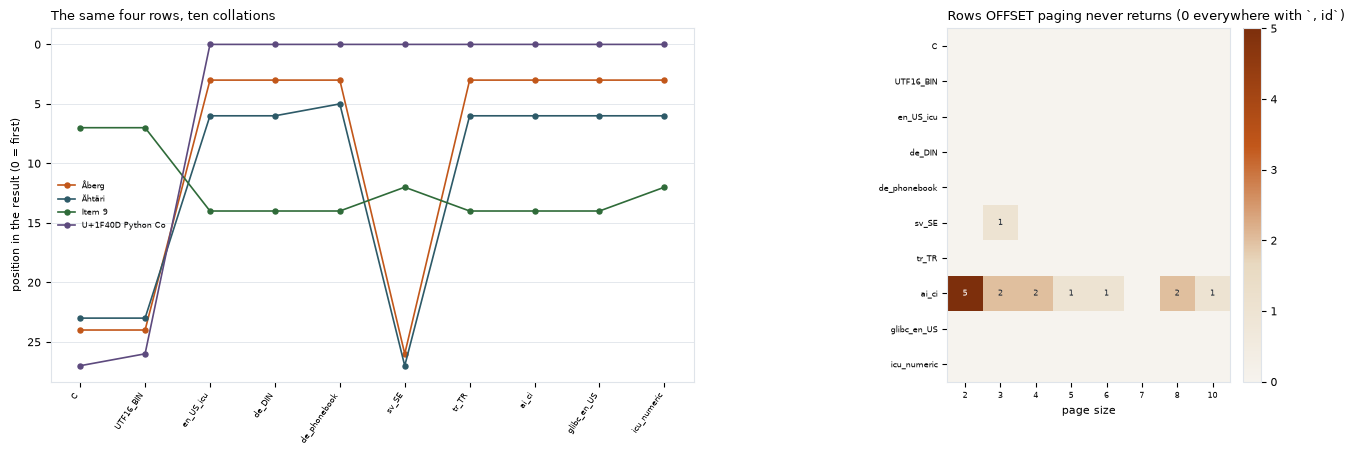

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

INK, WARM, COOL, GREEN, SAND, GRID = "#1d2733", "#c2571a", "#2d5a68", "#2f6b39", "#e8d9c0", "#dfe4ea"
plt.rcParams.update({"font.size": 8, "figure.facecolor": "white", "axes.edgecolor": GRID})
NAMES = [c.key_name for c in COLLATIONS]


def chart_label(name):
    return "".join(ch if ord(ch) < 0x2000 else f"U+{ord(ch):04X}" for ch in name)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

for rid, col in zip([2, 5, 21, 27], [WARM, COOL, GREEN, "#5d4a7e"]):
    ax1.plot(range(len(NAMES)), [pos[n][rid] for n in NAMES], "-o", ms=3.6, lw=1.2,
             color=col, label=chart_label(CORPUS[rid - 1].name))
ax1.set_xticks(range(len(NAMES)))
ax1.set_xticklabels(NAMES, rotation=55, ha="right", fontsize=6)
ax1.invert_yaxis()
ax1.set_ylabel("position in the result (0 = first)")
ax1.grid(axis="y", color=GRID, lw=0.6)
ax1.set_axisbelow(True)
ax1.legend(fontsize=6, frameon=False, loc="center left")
ax1.set_title("The same four rows, ten collations", fontsize=9, loc="left")

grid = np.zeros((len(NAMES), len(PAGE_SIZES)))
for i, c in enumerate(COLLATIONS):
    for j, n in enumerate(PAGE_SIZES):
        grid[i, j] = len(offset_pagination(c, n)[0])
im = ax2.imshow(grid, cmap=matplotlib.colors.LinearSegmentedColormap.from_list(
    "h", ["#f6f3ee", SAND, WARM, "#7d2f0c"]), vmin=0, vmax=max(1, grid.max()))
ax2.set_xticks(range(len(PAGE_SIZES)))
ax2.set_xticklabels([str(n) for n in PAGE_SIZES], fontsize=6)
ax2.set_yticks(range(len(NAMES)))
ax2.set_yticklabels(NAMES, fontsize=6)
ax2.set_xlabel("page size")
for i in range(len(NAMES)):
    for j in range(len(PAGE_SIZES)):
        if grid[i, j]:
            ax2.text(j, i, int(grid[i, j]), ha="center", va="center", fontsize=6,
                     color="white" if grid[i, j] > grid.max() * 0.55 else INK)
ax2.set_title("Rows OFFSET paging never returns (0 everywhere with `, id`)", fontsize=9, loc="left")
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.02)
fig.tight_layout()
fig.savefig("sort_order_notebook.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary, and the fix

| mechanism | number |
|---|---|
| collation pairs returning the identical sequence | 1 of 45 |
| verdicts | 2 stable-total, 0 total, 7 tied, 1 merging |
| `COUNT(DISTINCT name)` under `ai_ci` | 19, not 28 |
| `UNIQUE(name)` pairs rejected under `ai_ci` | 10 |
| OFFSET runs that are wrong | 8 of 80 |
| rows OFFSET paging never returns | 15 |
| rows keyset `>` never returns | 24 |
| keyset `>=` runs that never terminate | 80 of 80 |
| rows matched by `name >= 'A' AND name < 'N'` | 16 to 21 |
| **all of the above, with `ORDER BY name, id`** | **0** |

The fix, cheapest first:

1. **`ORDER BY name, id`** - one clause, and every pagination number above goes to zero.
2. **Keyset on a composite** - `WHERE (name, id) > ($n, $i) ORDER BY name, id`. Strictly advances, so it terminates.
3. **Name the collation in the DDL** rather than inheriting the host's `lc_collate`.
4. **Normalise on write** (NFC) - no collation can undo two spellings of one string in a byte-ordered index.
5. **Decide determinism deliberately** - nondeterministic gives you case-insensitive uniqueness *and* changes `DISTINCT`/`GROUP BY`. Both are defensible; the accident is not.
6. **Treat the collation version as a migration input** - glibc 2.28 changed `en_US.UTF-8` and invalidated existing PostgreSQL text indexes.


In [11]:
# Verification: the counts this notebook computed, asserted against the
# numbers published in the README (which evidence.py prints from collate.py).
checks = {
    "identical collation pairs": (len(identical), 1),
    "tied collations": (sum(1 for c in COLLATIONS if verdict(c) is Verdict.TIED), 7),
    "merging collations": (sum(1 for c in COLLATIONS if verdict(c) is Verdict.MERGING), 1),
    "total collations": (sum(1 for c in COLLATIONS if verdict(c) is Verdict.TOTAL), 0),
    "DISTINCT under ai_ci": (distinct_count(ai), 19),
    "UNIQUE violations under ai_ci": (len(violations), 10),
    "dirty OFFSET runs": (int((pag.offset_lost > 0).sum()), 8),
    "rows lost by OFFSET": (int(pag.offset_lost.sum()), 15),
    "rows lost by keyset `>`": (int(pag.keyset_gt_lost.sum()), 24),
    "keyset `>=` stalls": (int(pag.keyset_ge_stall.sum()), 80),
    "wrong rows with `, id`": (int(pag.with_id.sum()), 0),
    "range predicate min..max": ((min(counts.values()), max(counts.values())), (16, 21)),
}
for label, (got, want) in checks.items():
    status = "ok " if got == want else "MISMATCH"
    print(f"  [{status}] {label:32s} {got} (expected {want})")
assert all(got == want for got, want in checks.values())
print("\nnotebook agrees with the engine on every headline count")

  [ok ] identical collation pairs        1 (expected 1)
  [ok ] tied collations                  7 (expected 7)
  [ok ] merging collations               1 (expected 1)
  [ok ] total collations                 0 (expected 0)
  [ok ] DISTINCT under ai_ci             19 (expected 19)
  [ok ] UNIQUE violations under ai_ci    10 (expected 10)
  [ok ] dirty OFFSET runs                8 (expected 8)
  [ok ] rows lost by OFFSET              15 (expected 15)
  [ok ] rows lost by keyset `>`          24 (expected 24)
  [ok ] keyset `>=` stalls               80 (expected 80)
  [ok ] wrong rows with `, id`           0 (expected 0)
  [ok ] range predicate min..max         (16, 21) (expected (16, 21))

notebook agrees with the engine on every headline count


## Try your own column

Paste your own names below - a real customer surname column, a product list, a
tag vocabulary - and see which collations tie it, and which page sizes lose a
row.


In [12]:
# MY_NAMES = """
# Ostergaard
# Østergaard
# Oestergaard
# o'brien
# O'Brien
# """.strip().splitlines()
#
# mine = tuple(Row(i, n.strip(), "") for i, n in enumerate(MY_NAMES, start=1))
# for c in COLLATIONS:
#     print(f"{c.key_name:13s} {verdict(c, mine).value:13s} "
#           f"{len(tie_groups(c, mine))} tie groups   "
#           f"first: {order(mine, c)[0].name!r}")
# for n in (2, 3, 4, 5):
#     lost, dup = offset_pagination(COLLATION_BY_NAME["ai_ci"], n, mine)
#     print(f"page size {n}: OFFSET lost {len(lost)}, repeated {len(dup)}")

---

**Day 150 of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
[project README](README.md) with every mechanism and the findings table,
`python evidence.py` for every number, `python -m pytest -q` for the 53 tests,
and `streamlit run app.py` to paste a column into the audit interactively.

Previous days on the same theme - an operation that looks total and is not:
[`currency-rounder`](../currency-rounder/) (Day 143),
[`filename-sanitiser`](../../automation-suite/filename-sanitiser/) (146),
[`duration-parser`](../../automation-suite/duration-parser/) (147),
[`percent-recomputer`](../../analytics-engineering-bi/percent-recomputer/) (148),
[`header-casing`](../../automation-suite/header-casing/) (149).
